# 1. Data Collection

In [2]:
# Download libraries
!pip -q install -U datasets==2.20.0 pyarrow==17.0.0 tqdm==4.66.5
!pip install vaderSentiment

from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import os, json
from pathlib import Path
from datetime import datetime
from datasets import load_dataset
import random, gzip
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import re
from collections import Counter

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.6/57.6 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 547.8/547.8 kB 12.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 39.9/39.9 MB 21.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.4/78.4 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 316.1/316.1 kB 24.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dataproc-spark-connect 0.8.3 requires tqdm>=4.67, but you have tqdm 4.66.5 which is incompatible.
gcsfs 2025.3.0 requires fsspec==2025.3.0, but you have fsspec 2024.5.0 which is incompatible.


**1.1 Row data download**

In [ ]:

YEARS = {2008, 2013, 2018, 2023}
SAVE_DIR = "/content/amazon_electronics_"
MAX_PER_YEAR = None
CSV_EXPORT = True
CSV_FIELDS = ["rating", "title", "text", "user_id", "timestamp", "asin"]

out_dir = Path(SAVE_DIR)
out_dir.mkdir(parents=True, exist_ok=True)

# Load dataset
ds_stream = load_dataset(
    "McAuley-Lab/Amazon-Reviews-2023",
    "raw_review_Electronics",
    split="full",
    streaming=True,
    trust_remote_code=True
)

# Convert timestamp to year
def to_year(ts):
    if ts is None:
        return None
    try:
        t = float(ts)
        if t > 1e12:
            dt = datetime.utcfromtimestamp(t / 1000.0)
        else:
            dt = datetime.utcfromtimestamp(t)
        return dt.year
    except Exception:
        return None

jsonl_paths = {year: out_dir / f"Electronics_{year}.jsonl" for year in YEARS}
writers = {year: open(path, "w", encoding="utf-8") for year, path in jsonl_paths.items()}

counts_total = {year: 0 for year in YEARS}

# Stream filtering and writing line by line
pbar = tqdm(desc="Streaming & filtering (Electronics)", unit="ex", mininterval=1.0)
for ex in ds_stream:
    rating = ex.get("rating", ex.get("overall"))
    title = ex.get("title", ex.get("summary"))
    text = ex.get("text", ex.get("reviewText"))
    user_id = ex.get("user_id", ex.get("reviewerID"))
    asin = ex.get("asin", ex.get("parent_asin"))
    ts = ex.get("timestamp", ex.get("unixReviewTime"))

    year = to_year(ts)
    if year not in YEARS:
        pbar.update(1)
        continue

    out_obj = {
        "rating": rating,
        "title": title,
        "text": text,
        "user_id": user_id,
        "asin": asin,
        "timestamp": ts,
        "year": year
    }

    if MAX_PER_YEAR is None or counts_total[year] < MAX_PER_YEAR:
        writers[year].write(json.dumps(out_obj, ensure_ascii=False) + "\n")
        counts_total[year] += 1

    if MAX_PER_YEAR is not None:
        done_all = all(c >= MAX_PER_YEAR for y, c in counts_total.items())
        if done_all:
            pbar.update(1)
            break

    pbar.update(1)

pbar.close()

for f in writers.values():
    f.close()

print("Done streaming.\nCounts per year:", counts_total)

# Export CSV
if CSV_EXPORT:
    import pandas as pd

    def jsonl_to_csv(in_path, out_path, fields):
        rows = []
        with open(in_path, "r", encoding="utf-8") as fin:
            for line in fin:
                obj = json.loads(line)
                row = {k: obj.get(k) for k in fields}
                rows.append(row)
        df = pd.DataFrame(rows)
        df.to_csv(out_path, index=False)

    for year in YEARS:
        in_jsonl = jsonl_paths[year]
        out_csv = out_dir / f"Electronics_{year}.csv"
        jsonl_to_csv(in_jsonl, out_csv, CSV_FIELDS)

print("\nFiles saved to:", str(out_dir.resolve()))


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Streaming & filtering (Electronics): 0ex [00:00, ?ex/s]

/tmp/ipython-input-425817284.py:36: DeprecationWarning: datetime.datetime.utcfromtimestamp() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.fromtimestamp(timestamp, datetime.UTC).
  dt = datetime.utcfromtimestamp(t / 1000.0)
/tmp/ipython-input-425817284.py:38: DeprecationWarning: datetime.datetime.utcfromtimestamp() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.fromtimestamp(timestamp, datetime.UTC).
  dt = datetime.utcfromtimestamp(t)


Done streaming.
Counts per year: {2008: 157531, 2018: 3911866, 2013: 1714533, 2023: 1912874}

Files saved to: /content/amazon_electronics_


**1.2 Data sampling**

As the original data is too big, we sample 10k data for each year to do analysis.

In [ ]:

def open_text_maybe_gzip(path):
    p = Path(path)
    if p.suffix == ".gz":
        return gzip.open(p, "rt", encoding="utf-8", errors="ignore")
    return open(p, "r", encoding="utf-8", errors="ignore")

def sample_jsonl_robust(in_path, out_path, k=100000, seed=42, report_every=500000):
    """
    Sample k JSON objects from a JSONL file using reservoir sampling.

    """
    random.seed(seed)
    reservoir = []
    seen = 0
    skipped = 0

    with open_text_maybe_gzip(in_path) as fin:
        for line in tqdm(fin, desc=f"Sampling {k} from {in_path}"):
            if not line.strip():
                skipped += 1
                continue

            try:
                obj = json.loads(line, strict=False)
            except json.JSONDecodeError:
                s = line.replace("\x00", "")
                try:
                    obj = json.loads(s, strict=False)
                except Exception:
                    skipped += 1
                    continue

            seen += 1
            if len(reservoir) < k:
                reservoir.append(obj)
            else:
                j = random.randint(1, seen)
                if j <= k:
                    reservoir[j-1] = obj

            if report_every and seen % report_every == 0:
                print(f"[progress] seen={seen:,} kept={len(reservoir):,} skipped={skipped:,}")

    with open(out_path, "w", encoding="utf-8") as fout:
        for obj in reservoir:
            fout.write(json.dumps(obj, ensure_ascii=False) + "\n")

    print(f"Done. Seen={seen:,}, Kept={len(reservoir):,}, Skipped(bad lines)={skipped:,}")


In [ ]:
sample_jsonl_robust("amazon_electronics_/Electronics_2008.jsonl", "Electronics_2008_sample.jsonl", k=100000)
sample_jsonl_robust("amazon_electronics_/Electronics_2013.jsonl", "Electronics_2013_sample.jsonl", k=100000)
sample_jsonl_robust("amazon_electronics_/Electronics_2018.jsonl", "Electronics_2018_sample.jsonl", k=100000)
sample_jsonl_robust("amazon_electronics_/Electronics_2023.jsonl", "Electronics_2023_sample.jsonl", k=100000)

Sampling 100000 from amazon_electronics_/Electronics_2008.jsonl: 157531it [00:03, 39864.77it/s]


Done. Seen=157,531, Kept=100,000, Skipped(bad lines)=0


Sampling 100000 from amazon_electronics_/Electronics_2013.jsonl: 512346it [00:07, 73525.20it/s]

[progress] seen=500,000 kept=100,000 skipped=0


Sampling 100000 from amazon_electronics_/Electronics_2013.jsonl: 1006626it [00:14, 50774.01it/s]

...

[progress] seen=1,000,000 kept=100,000 skipped=0


Sampling 100000 from amazon_electronics_/Electronics_2023.jsonl: 1507523it [00:24, 50812.92it/s]

[progress] seen=1,500,000 kept=100,000 skipped=0


Sampling 100000 from amazon_electronics_/Electronics_2023.jsonl: 1912874it [00:29, 63847.08it/s]


Done. Seen=1,912,874, Kept=100,000, Skipped(bad lines)=0


 **1.3 Data Overview**

In [ ]:
# Read the sampled data
df08 = pd.read_json("Electronics_2008_sample.jsonl", lines=True)
df13 = pd.read_json("Electronics_2013_sample.jsonl", lines=True)
df18 = pd.read_json("Electronics_2018_sample.jsonl", lines=True)
df23 = pd.read_json("Electronics_2023_sample.jsonl", lines=True)

print(df08.head())
print(df23.head())

   rating                                              title  \
0       5  5 stars but be careful that you get what you p...   
1       5                                    A+ Awsome fan!!   
2       5       Great Printer for the Technically Challenged   
3       4                            Nice case for the price   
4       1                                 LCD Screen Cracked   

                                                text  \
0  Bought four of these to use in a RAID.  All fo...   
1  I bought this fan for my Xbox 360. It is nice!...   
2  I wanted a new printer to use for a multitude ...   
3  I agree with most of the other reviews on here...   
4  I bought a 30 GB Zune for my grandson for Chri...   

                        user_id        asin           timestamp  year  
0  AEAUZK2OLWXD75AWJOCCGGCL3H2A  B000EY5F5C 2008-06-30 17:52:31  2008  
1  AF2HAVSLJCR32AMARVDPASBJ4HWQ  B00080G0BK 2008-02-01 04:00:38  2008  
2  AFSKPY37N3C43SOI5IEXEK5JSIYA  B000V2MK00 2008-05-13 19:42:4

Get the basic information of these 4 sampled datasets

Length of 2008 reviews: 100000
Length of 2013 reviews: 100000
Length of 2018 reviews: 100000
Length of 2023 reviews: 100000

2008 Star Rating Distribution (proportion):
rating
1    0.10596
2    0.05843
3    0.07909
4    0.22640
5    0.53012
Name: proportion, dtype: float64

2013 Star Rating Distribution (proportion):
rating
1    0.09077
2    0.05451
3    0.08229
4    0.18801
5    0.58442
Name: proportion, dtype: float64

2018 Star Rating Distribution (proportion):
rating
1    0.12118
2    0.04976
3    0.06029
4    0.11837
5    0.65040
Name: proportion, dtype: float64

2023 Star Rating Distribution (proportion):
rating
1    0.15298
2    0.05493
3    0.06479
4    0.10459
5    0.62271
Name: proportion, dtype: float64


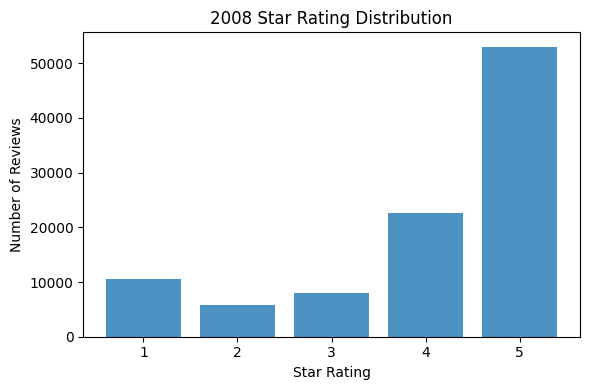

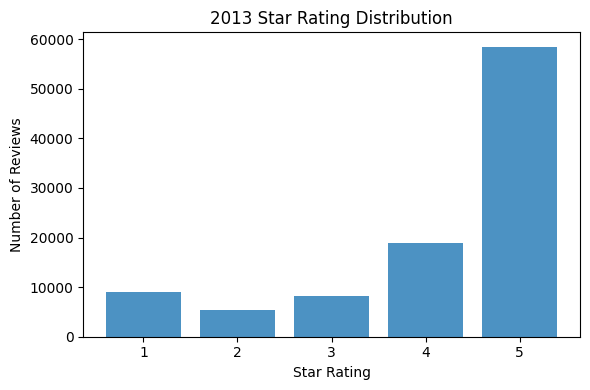

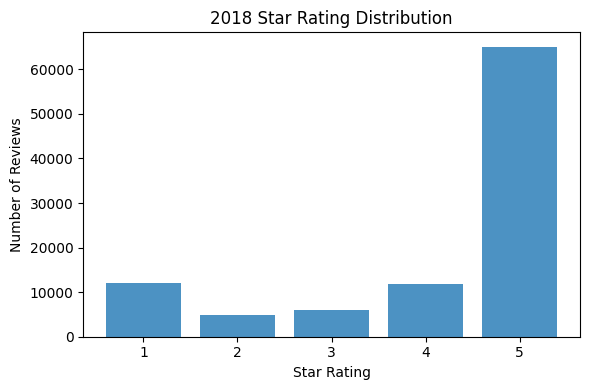

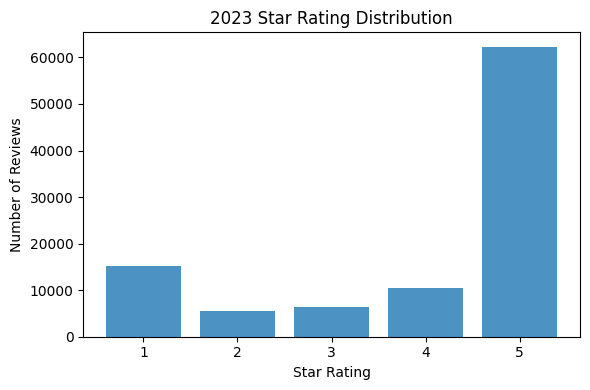


2008 Review Length (words):
count    100000.000000
mean        121.702880
std         147.686393
min           1.000000
25%          41.000000
50%          78.000000
75%         144.000000
max        5989.000000
Name: len_words, dtype: float64

2008 Review Length (characters):
count    100000.000000
mean        664.744590
std         820.587647
min           2.000000
25%         221.000000
50%         419.000000
75%         781.000000
max       32500.000000
Name: len_chars, dtype: float64

2013 Review Length (words):
count    100000.000000
mean         71.179630
std         103.217518
min           1.000000
25%          25.000000
50%          40.000000
75%          77.000000
max        5939.000000
Name: len_words, dtype: float64

2013 Review Length (characters):
count    100000.000000
mean        384.089770
std         573.200084
min           1.000000
25%         135.000000
50%         210.000000
75%         410.000000
max       32122.000000
Name: len_chars, dtype: float64

2018 Revi

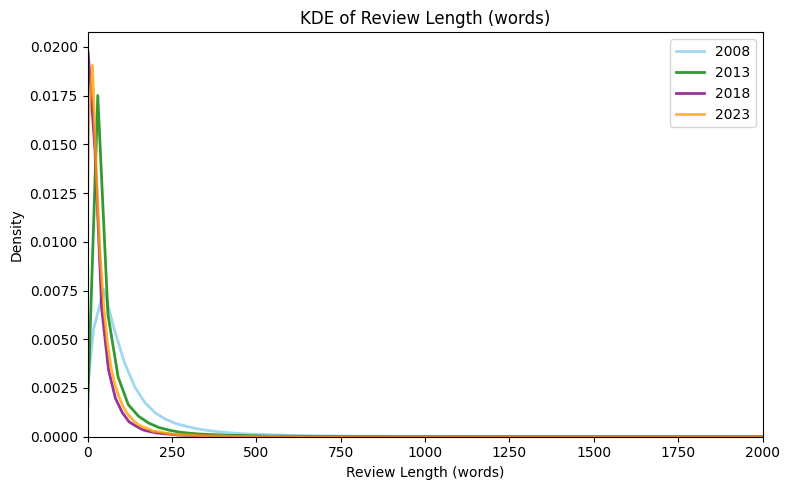

/tmp/ipython-input-270580103.py:73: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_box, x="year", y="len_words", palette=colors.values())


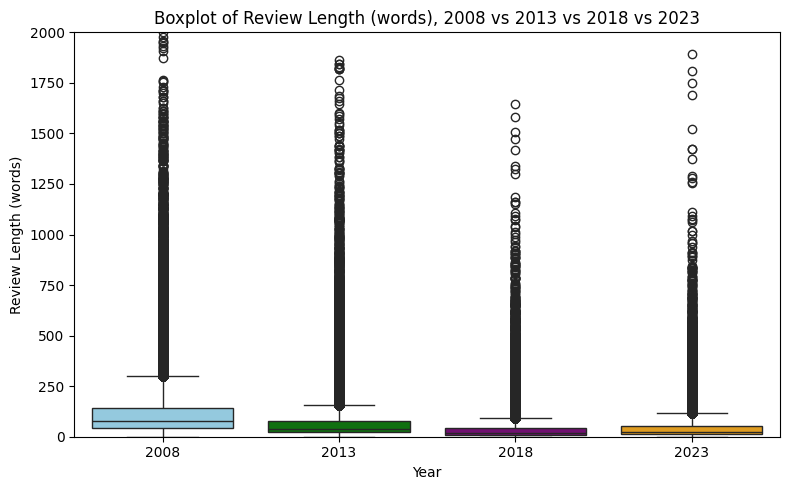

In [ ]:
dfs = {
    2008: df08,
    2013: df13,
    2018: df18,
    2023: df23
}

# Review lengths
for year, df in dfs.items():
    print(f"Length of {year} reviews:", len(df))

# Star Rating Distribution
for year, df in dfs.items():
    print(f"\n{year} Star Rating Distribution (proportion):")
    print(df["rating"].value_counts(normalize=True).sort_index())

# Star Rating Distribution (histogram)
for year, df in dfs.items():
    dist = df["rating"].value_counts().sort_index()
    plt.figure(figsize=(6,4))
    plt.bar(dist.index, dist.values, alpha=0.8)
    plt.title(f"{year} Star Rating Distribution")
    plt.xlabel("Star Rating")
    plt.ylabel("Number of Reviews")
    plt.tight_layout()
    plt.show()

# Review Length Statistics
for year, df in dfs.items():
    df["len_words"] = df["text"].astype(str).str.split().str.len()
    df["len_chars"] = df["text"].astype(str).str.len()

    print(f"\n{year} Review Length (words):")
    print(df["len_words"].describe([0.25, 0.5, 0.75]))

    print(f"\n{year} Review Length (characters):")
    print(df["len_chars"].describe([0.25, 0.5, 0.75]))

#  Review Length Distribution (histogram)
plt.figure(figsize=(8,5))
colors = {2008:"skyblue", 2013:"green", 2018:"purple", 2023:"orange"}

for year, df in dfs.items():
    sns.kdeplot(
        df["len_words"],
        label=str(year),
        color=colors[year],
        fill=False,
        alpha=0.8,
        linewidth=2
    )

plt.xlim(0, 2000)
plt.xlabel("Review Length (words)")
plt.ylabel("Density")
plt.title("KDE of Review Length (words)")
plt.legend()
plt.tight_layout()
plt.show()


# Review Length Boxplot
df_box = pd.concat([
    pd.DataFrame({"len_words": df["len_words"], "year": str(year)})
    for year, df in dfs.items()
])
plt.figure(figsize=(8,5))
sns.boxplot(data=df_box, x="year", y="len_words", palette=colors.values())
plt.ylim(0, 2000)
plt.ylabel("Review Length (words)")
plt.xlabel("Year")
plt.title("Boxplot of Review Length (words), 2008 vs 2013 vs 2018 vs 2023")
plt.tight_layout()
plt.show()


# 2. Data analysis

**2.1 Calculate the complete VADER sentiment**

In [ ]:
analyzer = SentimentIntensityAnalyzer()

def add_vader_scores(df):
    """
    Calculate the complete VADER sentiment scores for every review

    """
    scores = df["text"].astype(str).apply(analyzer.polarity_scores)
    scores_df = pd.DataFrame(list(scores))
    return pd.concat([df.reset_index(drop=True), scores_df[["compound","pos","neg"]]], axis=1)

df08 = add_vader_scores(df08)
df13 = add_vader_scores(df13)
df18 = add_vader_scores(df18)
df23 = add_vader_scores(df23)

print(df08[["text","compound","pos","neg"]].head())


                                                text  compound    pos    neg
0  Bought four of these to use in a RAID.  All fo...    0.0000  0.000  0.000
1  I bought this fan for my Xbox 360. It is nice!...    0.9038  0.375  0.000
2  I wanted a new printer to use for a multitude ...    0.5363  0.081  0.060
3  I agree with most of the other reviews on here...    0.8719  0.149  0.060
4  I bought a 30 GB Zune for my grandson for Chri...   -0.7988  0.121  0.136


Calculate average vader scores for each year

In [ ]:
print("=== Global Averages ===")
print("2008:")
print(df08[["compound","pos","neg"]].mean())

print("2013:")
print(df13[["compound","pos","neg"]].mean())

print("2018:")
print(df18[["compound","pos","neg"]].mean())

print("\n2023:")
print(df23[["compound","pos","neg"]].mean())


=== Global Averages ===
2008:
compound    0.598930
pos         0.150723
neg         0.040543
dtype: float64
2013:
compound    0.541184
pos         0.171865
neg         0.039632
dtype: float64
2018:
compound    0.445270
pos         0.273141
neg         0.041240
dtype: float64

2023:
compound    0.416745
pos         0.210651
neg         0.045087
dtype: float64


Visualize Global VADER Sentiment Trends (2008–2023)

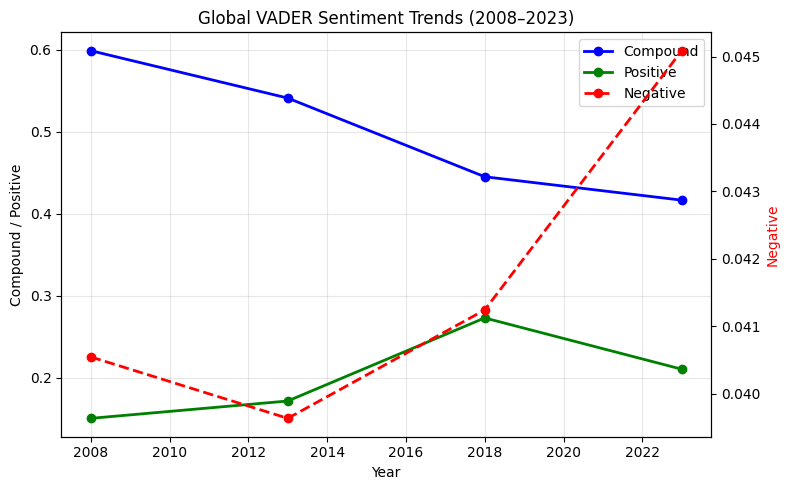

In [ ]:

years = [2008, 2013, 2018, 2023]
compound = [0.598930, 0.541184, 0.445270, 0.416745]
pos = [0.150723, 0.171865, 0.273141, 0.210651]
neg = [0.040543, 0.039632, 0.041240, 0.045087]

fig, ax1 = plt.subplots(figsize=(8,5))

ax1.plot(years, compound, marker="o", color="blue", label="Compound", linewidth=2)
ax1.plot(years, pos, marker="o", color="green", label="Positive", linewidth=2)
ax1.set_ylabel("Compound / Positive", color="black")

ax2 = ax1.twinx()
ax2.plot(years, neg, marker="o", color="red", label="Negative", linewidth=2, linestyle="--")
ax2.set_ylabel("Negative", color="red")

ax1.set_title("Global VADER Sentiment Trends (2008–2023)")
ax1.set_xlabel("Year")
ax1.grid(alpha=0.3)

lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines+lines2, labels+labels2, loc="best")

plt.tight_layout()
plt.show()



**2.2 Get VADER sentiment trends for positive and negetive reviews**

Divid Data into Positive and Negetive

1-2 stars ------ negative

4-5 stars ------ positive

In [ ]:
def classify(rating):
    if rating in [4, 5]:
        return "Positive"
    elif rating in [1, 2]:
        return "Negative"
    else:
        return "Neutral"

df08['rating_class'] = df08['rating'].apply(classify)
df13['rating_class'] = df13['rating'].apply(classify)
df18['rating_class'] = df18['rating'].apply(classify)
df23['rating_class'] = df23['rating'].apply(classify)


In [ ]:
# Divid Data into Positive and Negetive for Each Year
df08_pos = df08[df08["rating_class"] == "Positive"].copy()
df08_neg = df08[df08["rating_class"] == "Negative"].copy()

df13_pos = df13[df13["rating_class"] == "Positive"].copy()
df13_neg = df13[df13["rating_class"] == "Negative"].copy()

df18_pos = df18[df18["rating_class"] == "Positive"].copy()
df18_neg = df18[df18["rating_class"] == "Negative"].copy()

df23_pos = df23[df23["rating_class"] == "Positive"].copy()
df23_neg = df23[df23["rating_class"] == "Negative"].copy()

for name, df in [("2008_Pos", df08_pos), ("2008_Neg", df08_neg),
                 ("2013_Pos", df13_pos), ("2013_Neg", df13_neg),
                 ("2018_Pos", df18_pos), ("2018_Neg", df18_neg),
                 ("2023_Pos", df23_pos), ("2023_Neg", df23_neg)]:
    print(f"{name}: {len(df)} reviews")


2008_Pos: 75652 reviews
2008_Neg: 16439 reviews
2013_Pos: 77243 reviews
2013_Neg: 14528 reviews
2018_Pos: 76877 reviews
2018_Neg: 17094 reviews
2023_Pos: 72730 reviews
2023_Neg: 20791 reviews


In [ ]:
import pandas as pd
dfs_split = {
    2008: {"Positive": df08_pos, "Negative": df08_neg},
    2013: {"Positive": df13_pos, "Negative": df13_neg},
    2018: {"Positive": df18_pos, "Negative": df18_neg},
    2023: {"Positive": df23_pos, "Negative": df23_neg},
}

metrics = ["compound", "pos", "neg"]
records = []

for year, groups in dfs_split.items():
    for cls in ["Positive", "Negative"]:   #
        df = groups.get(cls)
        if df is None or df.empty:
            row = {m: float("nan") for m in metrics}
            row.update({"Year": year, "Class": cls, "n": 0})
        else:
            row = {m: df[m].mean() for m in metrics}
            row.update({"Year": year, "Class": cls, "n": len(df)})
        records.append(row)

summary_df = pd.DataFrame(records)

summary_pivot = summary_df.pivot(index="Year", columns="Class", values=metrics)
print("=== Means (by Year × Class) ===")
print(summary_pivot.round(4))


=== Means (by Year × Class) ===
      compound               pos               neg         
Class Negative Positive Negative Positive Negative Positive
Year                                                       
2008    0.0499   0.7365   0.0806   0.1702   0.0793   0.0305
2013   -0.0207   0.6710   0.0750   0.1965   0.0873   0.0286
2018   -0.0922   0.5834   0.0660   0.3307   0.1152   0.0224
2023   -0.0969   0.5834   0.0652   0.2610   0.1088   0.0243


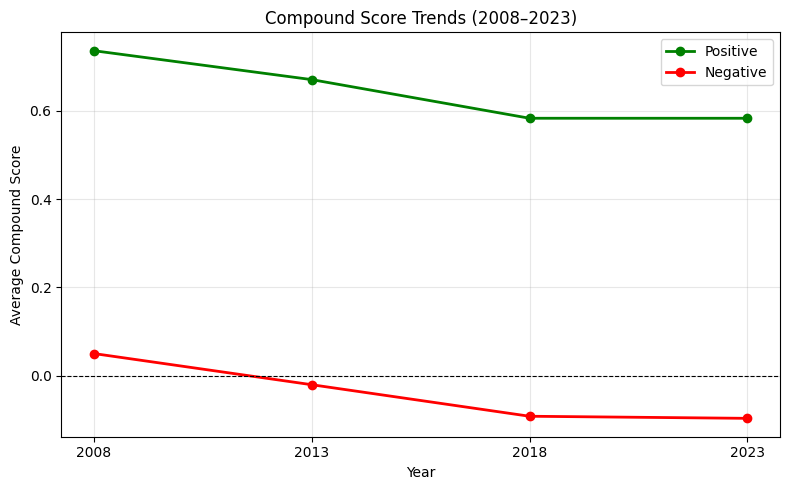

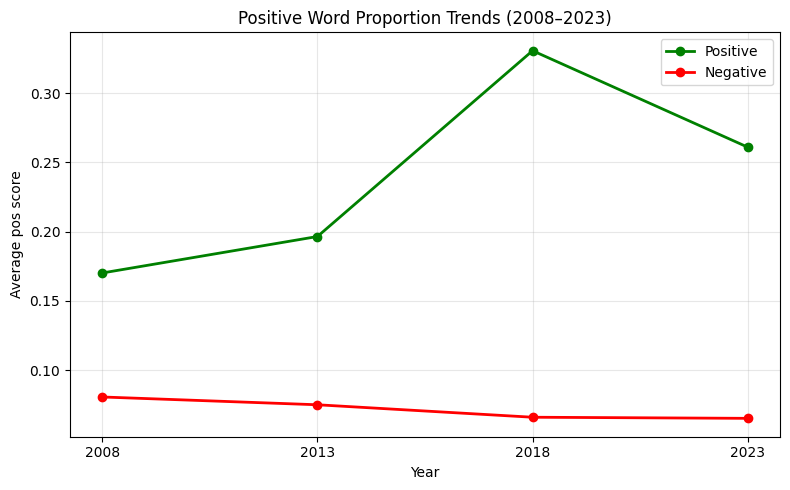

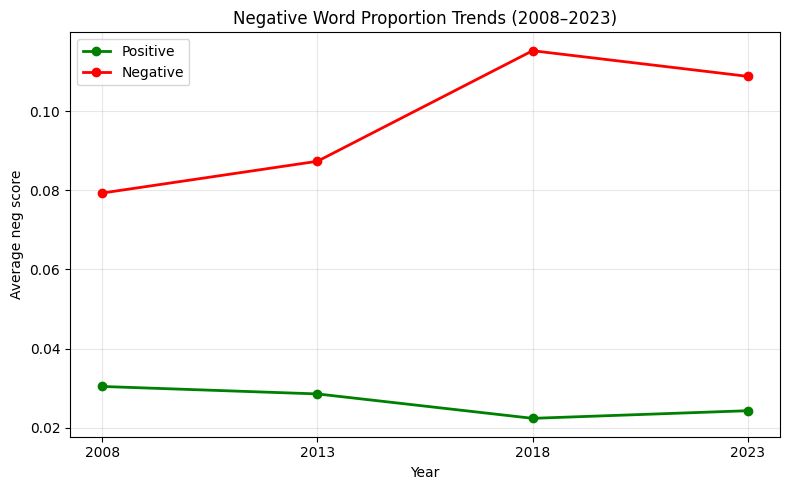

In [ ]:
years = [2008, 2013, 2018, 2023]
metrics = {
    "compound": {
        "title": "Compound Score Trends (2008–2023)",
        "ylabel": "Average Compound Score"
    },
    "pos": {
        "title": "Positive Word Proportion Trends (2008–2023)",
        "ylabel": "Average pos score"
    },
    "neg": {
        "title": "Negative Word Proportion Trends (2008–2023)",
        "ylabel": "Average neg score"
    }
}

for metric, info in metrics.items():
    pos_vals = [summary_pivot.loc[y, (metric, "Positive")] for y in years]
    neg_vals = [summary_pivot.loc[y, (metric, "Negative")] for y in years]

    plt.figure(figsize=(8,5))
    plt.plot(years, pos_vals, marker="o", label="Positive", color="green", linewidth=2)
    plt.plot(years, neg_vals, marker="o", label="Negative", color="red", linewidth=2)

    if metric == "compound":
        plt.axhline(0, color="black", linestyle="--", linewidth=0.8)

    plt.title(info["title"])
    plt.xlabel("Year")
    plt.ylabel(info["ylabel"])
    plt.xticks(years)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


**2.3 Language diversity and comprehensiveness**

In [ ]:


# 1) Extract the VADER lexicon and define the set
analyzer = SentimentIntensityAnalyzer()
lex = analyzer.lexicon  # dict: word -> valence (e.g., 'amazing': 3.2)

POS = {w for w, v in lex.items() if v > 0}
NEG = {w for w, v in lex.items() if v < 0}
SENT = POS | NEG

POS_EXT = {w for w, v in lex.items() if v >= 3.0}
NEG_EXT = {w for w, v in lex.items() if v <= -3.0}
EXTREME = POS_EXT | NEG_EXT  # Set of extreme sentiment words

# 2) Simple English tokenization (match words and words with apostrophes, such as "don't")
token_re = re.compile(r"[A-Za-z]+(?:'[A-Za-z]+)?")
def tokenize(s: str):
    return token_re.findall(str(s).lower())

# 3) Count sentiment words and extreme words in a DataFrame
def sentiment_counters(df: pd.DataFrame):
    total_tokens = 0
    sent_counter = Counter()
    extreme_count = 0

    for text in df["text"].astype(str):
        toks = tokenize(text)
        total_tokens += len(toks)
        for t in toks:
            if t in SENT:
                sent_counter[t] += 1
                if t in EXTREME:
                    extreme_count += 1
    return total_tokens, sent_counter, extreme_count

# 4) Summary metrics (proportion of extreme words, top 1% coverage, etc.)
def summarize_year(df: pd.DataFrame):
    total_tokens, sent_counter, extreme_count = sentiment_counters(df)
    sent_total = sum(sent_counter.values())
    n_types = len(sent_counter)

    # Coverage rate of top 1% high-frequency sentiment word types
    topk = max(1, int(round(0.01 * n_types)))
    top_types = sent_counter.most_common(topk)
    top_types_sum = sum(c for _, c in top_types)

    stats = {
        "n_reviews": len(df),
        "total_words": total_tokens,
        "sentiment_tokens": sent_total,
        "extreme_tokens": extreme_count,
        # Proportion of extreme words among all words
        "extreme_share_of_all_words": (extreme_count / total_tokens) if total_tokens else 0.0,
        # Proportion of extreme words among sentiment words
        "extreme_share_of_sentiment": (extreme_count / sent_total) if sent_total else 0.0,
        "n_sentiment_types": n_types,
        "top1pct_types": topk,
        # Proportion of the top 1% most frequent sentiment word types in all sentiment word tokens
        "top1pct_share_of_sentiment": (top_types_sum / sent_total) if sent_total else 0.0,
    }
    return stats, sent_counter

# 5) Run code for each 4 years
dfs = {2008: df08, 2013: df13, 2018: df18, 2023: df23}

year_stats = {}
year_counters = {}

for y, df in dfs.items():
    stats, counter = summarize_year(df)
    year_stats[y] = stats
    year_counters[y] = counter

summary_extreme = pd.DataFrame.from_dict(year_stats, orient="index").sort_index()
print("=== Extreme Sentiment Words — Yearly Summary ===")
print(summary_extreme.round(6))

# 6) List the top extreme words by year
def top_extreme_words(counter: Counter, k=20):
    items = [(w, c) for w, c in counter.items() if w in EXTREME]
    return sorted(items, key=lambda x: x[1], reverse=True)[:k]

for y in [2008, 2013, 2018, 2023]:
    te = top_extreme_words(year_counters[y], k=20)
    print(f"\nTop extreme words in {y}:")
    for w, c in te:
        print(f"{w:>15} : {c}")


=== Extreme Sentiment Words — Yearly Summary ===
      n_reviews  total_words  sentiment_tokens  extreme_tokens  \
2008     100000     12249211            871819           84670   
2013     100000      7139530            553742           62188   
2018     100000      3635417            325688           48784   
2023     100000      4447314            369048           43814   

      extreme_share_of_all_words  extreme_share_of_sentiment  \
2008                    0.006912                    0.097119   
2013                    0.008710                    0.112305   
2018                    0.013419                    0.149788   
2023                    0.009852                    0.118722   

      n_sentiment_types  top1pct_types  top1pct_share_of_sentiment  
2008               3468             35                    0.508069  
2013               3048             30                    0.509215  
2018               2582             26                    0.511686  
2023               2668

In [ ]:
TOP_K = 20

def top_extreme_df_for_year(y, counter, year_summary_row):
    sent_total = year_summary_row["sentiment_tokens"]
    total_words = year_summary_row["total_words"]
    items = [(w, c) for w, c in counter.items() if w in EXTREME]
    items.sort(key=lambda x: x[1], reverse=True)
    rows = []
    for rank, (w, c) in enumerate(items[:TOP_K], start=1):
        share_senti = (c / sent_total) if sent_total else 0.0
        share_all = (c / total_words) if total_words else 0.0
        rows.append({
            "year": y,
            "rank": rank,
            "word": w,
            "count": c,
            "share_of_sentiment": share_senti,
            "share_of_all_words": share_all
        })
    return pd.DataFrame(rows)

all_top_extreme = []
for y in sorted(dfs.keys()):
    df_year = top_extreme_df_for_year(y, year_counters[y], summary_extreme.loc[y])
    all_top_extreme.append(df_year)

top_extreme_allyears = pd.concat(all_top_extreme, ignore_index=True)

print("\n=== Top Extreme Words (All Years, with proportions) ===")
print(top_extreme_allyears.head(40).to_string(index=False))


# =========================
# 6.2 （可选）若存在 rating_class，则按 Positive/Negative 再细分
# =========================
def has_rating_class(df_dict):
    # 只要任一年里有 rating_class 列，就视为可用
    return any("rating_class" in df.columns for df in df_dict.values())

if has_rating_class(dfs):
    print("\n=== Detected 'rating_class' — producing Year × Group breakdown ===")
    groups = ["Positive", "Negative"]

    def summarize_year_group(df_group: pd.DataFrame):
        total_tokens, sent_counter, extreme_count = sentiment_counters(df_group)
        sent_total = sum(sent_counter.values())
        n_types = len(sent_counter)
        topk = max(1, int(round(0.01 * n_types)))
        top_types = sent_counter.most_common(topk)
        top_types_sum = sum(c for _, c in top_types)
        stats = {
            "n_reviews": len(df_group),
            "total_words": total_tokens,
            "sentiment_tokens": sent_total,
            "extreme_tokens": extreme_count,
            "extreme_share_of_all_words": (extreme_count / total_tokens) if total_tokens else 0.0,
            "extreme_share_of_sentiment": (extreme_count / sent_total) if sent_total else 0.0,
            "n_sentiment_types": n_types,
            "top1pct_types": topk,
            "top1pct_share_of_sentiment": (top_types_sum / sent_total) if sent_total else 0.0,
        }
        return stats, sent_counter

    year_group_stats = {}
    year_group_counters = {}

    for y, df in dfs.items():
        for grp in groups:
            sub = df[df["rating_class"] == grp]
            stats_g, counter_g = summarize_year_group(sub)
            year_group_stats[(y, grp)] = stats_g
            year_group_counters[(y, grp)] = counter_g

    summary_extreme_by_group = (
        pd.DataFrame.from_dict(year_group_stats, orient="index")
          .rename_axis(index=["Year","Group"])
          .sort_index()
    )
    print("\n=== Extreme Sentiment Words — Summary by Year × Group ===")
    print(summary_extreme_by_group.round(6))

    # Year × Group
    rows = []
    for (y, grp), counter_g in year_group_counters.items():
        sent_total = summary_extreme_by_group.loc[(y, grp), "sentiment_tokens"]
        total_words = summary_extreme_by_group.loc[(y, grp), "total_words"]
        items = [(w, c) for w, c in counter_g.items() if w in EXTREME]
        items.sort(key=lambda x: x[1], reverse=True)
        for rank, (w, c) in enumerate(items[:TOP_K], start=1):
            rows.append({
                "year": y,
                "group": grp,
                "rank": rank,
                "word": w,
                "count": c,
                "share_of_sentiment": (c / sent_total) if sent_total else 0.0,
                "share_of_all_words": (c / total_words) if total_words else 0.0
            })
    top_extreme_by_group = pd.DataFrame(rows)
    print("\n=== Top Extreme Words by Year × Group (Top K with proportions) ===")
    print(top_extreme_by_group.head(40).to_string(index=False))



=== Top Extreme Words (All Years, with proportions) ===
 year  rank        word  count  share_of_sentiment  share_of_all_words
 2008     1       great  46230            0.053027            0.003774
 2008     2        best  12330            0.014143            0.001007
 2008     3        love  11915            0.013667            0.000973
 2008     4   perfectly   3801            0.004360            0.000310
 2008     5     awesome   3056            0.003505            0.000249
 2008     6        dead   1356            0.001555            0.000111
 2008     7 outstanding   1080            0.001239            0.000088
 2008     8       worst    863            0.000990            0.000070
 2008     9      superb    779            0.000894            0.000064
 2008    10    greatest    390            0.000447            0.000032
 2008    11       heart    326            0.000374            0.000027
 2008    12    gorgeous    268            0.000307            0.000022
 2008    13         

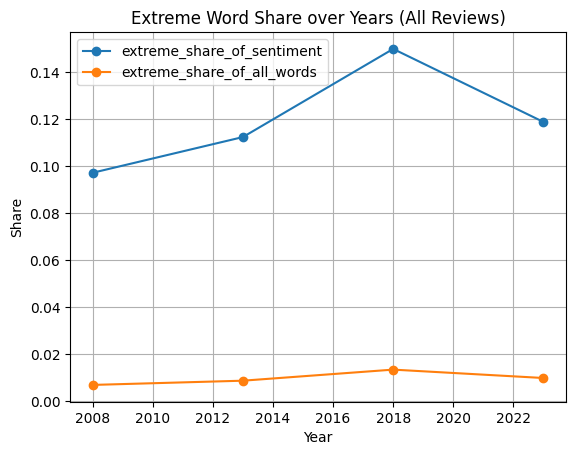

In [ ]:
# 1) Overall (ungrouped) extreme word share across years
import matplotlib.pyplot as plt

summary_extreme_plot = summary_extreme.copy()
summary_extreme_plot = summary_extreme_plot.sort_index()

plt.figure()
ycols = [c for c in ["extreme_share_of_sentiment", "extreme_share_of_all_words"] if c in summary_extreme_plot.columns]
for col in ycols:
    plt.plot(summary_extreme_plot.index, summary_extreme_plot[col], marker='o', label=col)

plt.title("Extreme Word Share over Years (All Reviews)")
plt.xlabel("Year")
plt.ylabel("Share")
if ycols:
    plt.legend()
plt.grid(True)
plt.show()


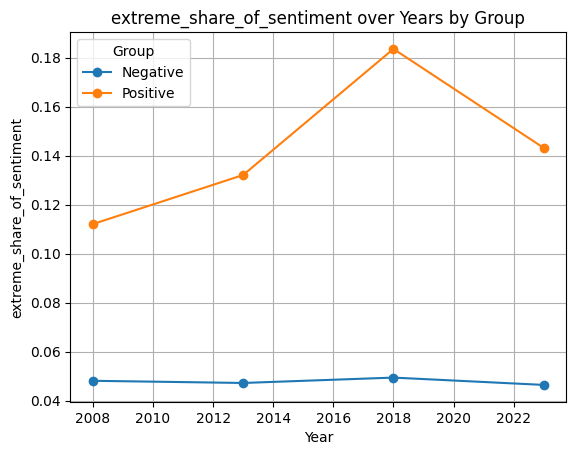

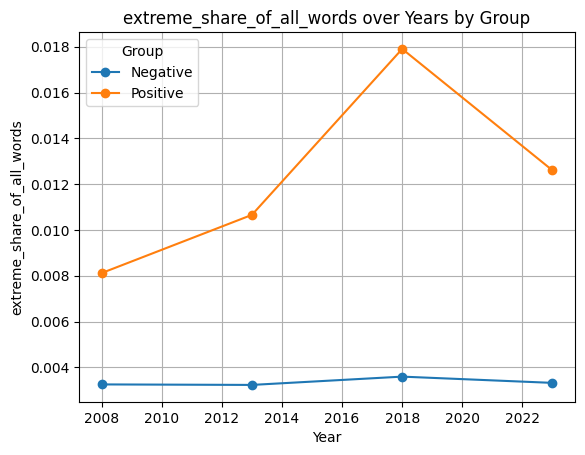

In [ ]:
# 2)  Grouped (positive/ negetive) extreme word share across years
import matplotlib.pyplot as plt
import pandas as pd

if 'summary_extreme_by_group' in globals():
    seg = summary_extreme_by_group.copy()
    seg = seg.sort_index()  # MultiIndex: (Year, Group)

    ycols = [c for c in ["extreme_share_of_sentiment", "extreme_share_of_all_words"] if c in seg.columns]
    if not ycols:
        if "extreme_ratio" in seg.columns:
            ycols = ["extreme_ratio"]

    for metric in ycols:
        pivot = seg.reset_index().pivot(index="Year", columns="Group", values=metric).sort_index()

        plt.figure()
        for grp in pivot.columns:
            plt.plot(pivot.index, pivot[grp], marker='o', label=f"{grp}")

        plt.title(f"{metric} over Years by Group")
        plt.xlabel("Year")
        plt.ylabel(metric)
        plt.legend(title="Group")
        plt.grid(True)
        plt.show()
else:
    print("Summary_extreme_by_group not detected, skipping grouped line chart.")


**Review Length and One-Sidedness Analysis**

In [ ]:

_analyzer = SentimentIntensityAnalyzer()
_LEX = _analyzer.lexicon  # word -> valence

_POS_WORDS = {w for w, v in _LEX.items() if v > 0}
_NEG_WORDS = {w for w, v in _LEX.items() if v < 0}

_NEGATE = set([
    "not","no","never","none","n't","dont","don't","didnt","didn't","cant","can't","wont","won't",
    "without","hardly","scarcely","rarely","seldom"
])

_TOKEN_RE = re.compile(r"[A-Za-z]+(?:'[A-Za-z]+)?")
def _tokenize(s: str):
    return _TOKEN_RE.findall(str(s).lower())

def _count_polar_tokens_with_negation(text: str, window=3):
    toks = _tokenize(text)
    pos = neg = 0
    for i, t in enumerate(toks):
        if t in _POS_WORDS or t in _NEG_WORDS:
            val = 1 if t in _POS_WORDS else -1
            lb = max(0, i - window)
            if any(tok in _NEGATE for tok in toks[lb:i]):
                val = -val
            if val > 0: pos += 1
            elif val < 0: neg += 1
    return pos, neg

def _is_one_sided(text: str, cls: str) -> bool:
    pos_cnt, neg_cnt = _count_polar_tokens_with_negation(text)
    if cls == "Positive":
        return (pos_cnt >= 1) and (neg_cnt == 0)
    elif cls == "Negative":
        return (neg_cnt >= 1) and (pos_cnt == 0)
    else:
        return False

def _review_word_count(s: str) -> int:
    return len(_tokenize(s))


In [ ]:
dfs_split = {}
try:
    _tmp = [
        ("2008", {"Positive": df08_pos, "Negative": df08_neg}),
        ("2013", {"Positive": df13_pos, "Negative": df13_neg}),
        ("2018", {"Positive": df18_pos, "Negative": df18_neg}),
        ("2023", {"Positive": df23_pos, "Negative": df23_neg}),
    ]

    dfs_split = {int(y): grp for y, grp in _tmp}
except NameError:

    base = {
        2008: df08, 2013: df13, 2018: df18, 2023: df23
    }
    for y, d in base.items():
        dfs_split[y] = {
            "Positive": d[d["rating_class"]=="Positive"].copy(),
            "Negative": d[d["rating_class"]=="Negative"].copy(),
        }


In [ ]:
from tqdm import tqdm

records = []
for year, groups in dfs_split.items():
    for cls, df in groups.items():
        if df.empty:
            records.append({
                "Year": year, "Class": cls, "n": 0,
                "avg_length_words": float("nan"),
                "one_sided_ratio": float("nan")
            })
            continue

        # Average length
        lengths = df["text"].astype(str).map(_review_word_count)
        avg_len = lengths.mean()

        # One-Sidedness
        flags = []
        for txt in tqdm(df["text"].astype(str), desc=f"{year}-{cls}", leave=False):
            flags.append(_is_one_sided(txt, cls))
        one_sided_ratio = (sum(flags) / len(flags)) if len(flags) else 0.0

        records.append({
            "Year": year,
            "Class": cls,
            "n": len(df),
            "avg_length_words": avg_len,
            "one_sided_ratio": one_sided_ratio
        })

summary_len_os = pd.DataFrame(records).sort_values(["Year","Class"])
print("=== Review length & One-sidedness (by Year × Class) ===")
print(summary_len_os)


=== Review length & One-sidedness (by Year × Class) ===
   Year     Class      n  avg_length_words  one_sided_ratio
1  2008  Negative  16439        125.581118         0.082183
0  2008  Positive  75652        119.443200         0.340467
3  2013  Negative  14528         84.956773         0.163959
2  2013  Positive  77243         67.129423         0.475810
5  2018  Negative  17094         49.100328         0.258219
4  2018  Positive  76877         31.977705         0.632751
7  2023  Negative  20791         46.514165         0.260161
6  2023  Positive  72730         42.299436         0.554627


/tmp/ipython-input-838724590.py:6: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  pos_vals = [float(summary_len_os.query("Year==@y & Class=='Positive'")[metric_key]) for y in years]
/tmp/ipython-input-838724590.py:6: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  pos_vals = [float(summary_len_os.query("Year==@y & Class=='Positive'")[metric_key]) for y in years]
/tmp/ipython-input-838724590.py:6: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  pos_vals = [float(summary_len_os.query("Year==@y & Class=='Positive'")[metric_key]) for y in years]
/tmp/ipython-input-838724590.py:6: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser

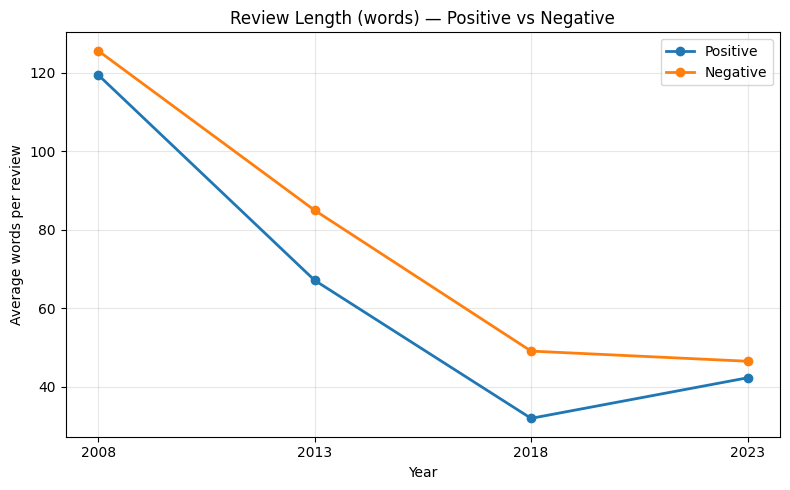

/tmp/ipython-input-838724590.py:6: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  pos_vals = [float(summary_len_os.query("Year==@y & Class=='Positive'")[metric_key]) for y in years]
/tmp/ipython-input-838724590.py:6: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  pos_vals = [float(summary_len_os.query("Year==@y & Class=='Positive'")[metric_key]) for y in years]
/tmp/ipython-input-838724590.py:6: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  pos_vals = [float(summary_len_os.query("Year==@y & Class=='Positive'")[metric_key]) for y in years]
/tmp/ipython-input-838724590.py:6: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser

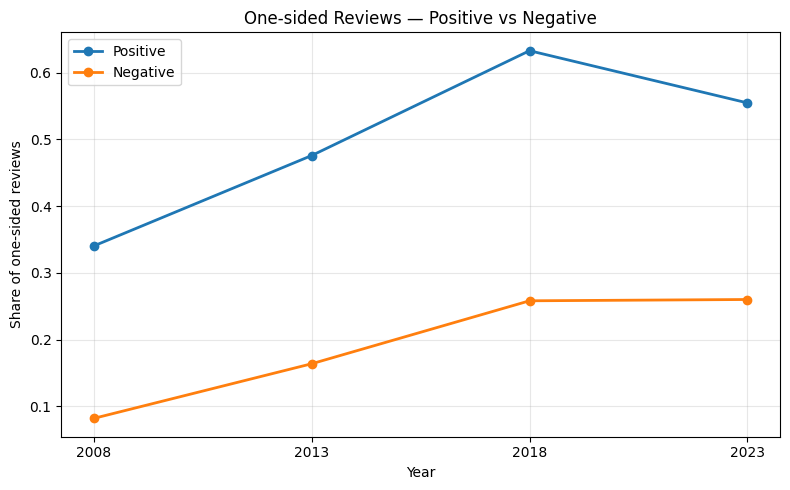

In [ ]:
import matplotlib.pyplot as plt

years = [2008, 2013, 2018, 2023]

def _plot_metric(metric_key, title, ylabel):
    pos_vals = [float(summary_len_os.query("Year==@y & Class=='Positive'")[metric_key]) for y in years]
    neg_vals = [float(summary_len_os.query("Year==@y & Class=='Negative'")[metric_key]) for y in years]
    plt.figure(figsize=(8,5))
    plt.plot(years, pos_vals, marker="o", linewidth=2, label="Positive")
    plt.plot(years, neg_vals, marker="o", linewidth=2, label="Negative")
    plt.xticks(years)
    plt.title(title); plt.xlabel("Year"); plt.ylabel(ylabel)
    plt.grid(alpha=0.3); plt.legend()
    plt.tight_layout(); plt.show()

# (a) 平均长度
_plot_metric("avg_length_words",
             "Review Length (words) — Positive vs Negative",
             "Average words per review")

# (b) 单极性比例
_plot_metric("one_sided_ratio",
             "One-sided Reviews — Positive vs Negative",
             "Share of one-sided reviews")


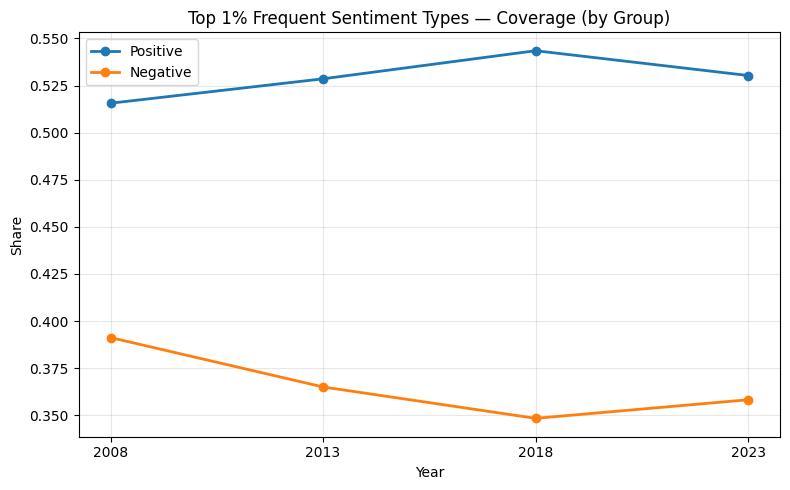

In [ ]:
if 'summary_extreme_by_group' in globals():
    def _plot_top1pct_share():
        pos_vals = [float(summary_extreme_by_group.loc[(y,"Positive"), "top1pct_share_of_sentiment"]) for y in years]
        neg_vals = [float(summary_extreme_by_group.loc[(y,"Negative"), "top1pct_share_of_sentiment"]) for y in years]
        plt.figure(figsize=(8,5))
        plt.plot(years, pos_vals, marker="o", linewidth=2, label="Positive")
        plt.plot(years, neg_vals, marker="o", linewidth=2, label="Negative")
        plt.xticks(years)
        plt.title("Top 1% Frequent Sentiment Types — Coverage (by Group)")
        plt.xlabel("Year"); plt.ylabel("Share")
        plt.grid(alpha=0.3); plt.legend()
        plt.tight_layout(); plt.show()
    _plot_top1pct_share()


**4.4	Illustrative Examples of Extreme Sentiment Words**

In [ ]:

dfs_year = {2008: df08, 2013: df13, 2018: df18, 2023: df23}

YEARS_TO_SHOW = [2008, 2023]
TOP_K = 10

# 1) Construct the VADER extreme word set
analyzer = SentimentIntensityAnalyzer()
lex = analyzer.lexicon  # word -> valence

# Thresholds: Positive ≥ +3; Negative ≤ −3
POS_EXT = {w for w, v in lex.items() if v >= 3.0}
NEG_EXT = {w for w, v in lex.items() if v <= -3.0}
LEX_SIZE = len(lex)

print("VADER lexicon size:", LEX_SIZE)
print("Extreme POS terms (>= +3):", len(POS_EXT), f"({len(POS_EXT)/LEX_SIZE:.1%} of lexicon)")
print("Extreme NEG terms (<= -3):", len(NEG_EXT), f"({len(NEG_EXT)/LEX_SIZE:.1%} of lexicon)")

# Tokenize
token_re = re.compile(r"[A-Za-z]+(?:'[A-Za-z]+)?")
def tokenize(s: str):
    return token_re.findall(str(s).lower())

# Select shortest reviews which contains extreme sentiment words
def shortest_intense_reviews(df: pd.DataFrame, group: str, top_k: int = 10):

    if group == "Positive":
        target_set = POS_EXT
    elif group == "Negative":
        target_set = NEG_EXT
    else:
        raise ValueError("group must be 'Positive' or 'Negative'")

    sub = df[df["rating_class"] == group].copy()
    rows = []
    for text in sub["text"].astype(str):
        toks = tokenize(text)
        if not toks:
            continue

        matched = sorted({t for t in toks if t in target_set})
        if matched:
            rows.append({
                "word_len": len(toks),
                "intense_terms": ", ".join(matched),
                "text": text
            })
    if not rows:
        return pd.DataFrame(columns=["word_len","intense_terms","text"])

    out = pd.DataFrame(rows).sort_values(["word_len","text"]).head(top_k)
    return out.reset_index(drop=True)

for year in YEARS_TO_SHOW:
    df = dfs_year[year]
    print(f"\n=== {year} Positive shortest intense reviews ===")
    display(shortest_intense_reviews(df, "Positive", TOP_K))

    print(f"\n=== {year} Negative shortest intense reviews ===")
    display(shortest_intense_reviews(df, "Negative", TOP_K))


VADER lexicon size: 7506
Extreme POS terms (>= +3): 58 (0.8% of lexicon)
Extreme NEG terms (<= -3): 140 (1.9% of lexicon)

=== 2008 Positive shortest intense reviews ===


,word_len,intense_terms,text
0,1,great,great
1,1,great,great
2,1,great,great
3,2,awesome,Awesome price!
4,2,great,Great product :)
5,2,great,Works great!
6,2,great,works great
7,4,great,GREAT PRODUCT FAST DELIVERY
8,4,great,Great RAM high speed.
9,4,great,Great product! Great service!



=== 2008 Negative shortest intense reviews ===


,word_len,intense_terms,text
0,13,dead,Dead on arrival. No answer at Mustek tech sup...
1,13,worst,Sucks! Suxs! Linksys has the worst software ...
2,15,dead,Bought this mouse about fews months ago and it...
3,16,dead,Dead in 30 min. Sent back for full refund. A...
4,16,dead,"Product only worked once, used it for 30min an..."
5,16,worst,The worst pair of earphone I have ever owned. ...
6,17,worst,These are the worst earbuds I've ever experien...
7,17,worst,This router needs rebooted constantly. I have...
8,18,dead,This does not work reliably. It often shows t...
9,19,dead,"Do not buy, not worth the effort to replace on..."



=== 2023 Positive shortest intense reviews ===


,word_len,intense_terms,text
0,1,awesome,AWESOME
1,1,awesome,Awesome
2,1,awesome,Awesome
3,1,awesome,Awesome
4,1,awesome,Awesome
5,1,awesome,Awesome
6,1,awesome,Awesome
7,1,awesome,Awesome
8,1,awesome,Awesome
9,1,awesome,Awesome



=== 2023 Negative shortest intense reviews ===


,word_len,intense_terms,text
0,1,worst,Worst
1,2,worst,Worst product
2,2,worst,Worst webcam
3,3,worst,Worst head phones
4,4,worst,The worst tv antenna.
5,4,worst,Worst flood light ever
6,4,dead,battery dead .after 2 month
7,5,killed,Killed my PSU! DONT BUY!!
8,5,worst,Worst reciever I've ever bought.
9,6,dead,Bought 09/2022 dead 01/2023 Fan dead - System...
